# Assay Plotter: Publication-Ready Dose-Response Analysis

This notebook generates high-resolution, scientific-standard plots for biochemical assays. 

### Features:
- **4PL Curve Fitting**: Uses 4-Parameter Logistic regression for high-precision sigmoidal modeling.
- **Scientific Aesthetics**: Replicates Nature/Science publication styles (thick axes, no grid, vibrant pink palette).
- **Error Bar Support**: Automatically parses `mean ± SD` formats for vertical error bars.
- **In-Chart Annotation**: IC50 values are displayed directly within the plot area.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import os
from scipy.optimize import curve_fit
from scipy.interpolate import make_interp_spline

def logistic4(x, a, b, c, d):
    """4-Parameter Logistic Curve for IC50 fitting."""
    return d + (a - d) / (1 + (x / c)**b)

def calculate_ic50(x_data, y_data):
    """Calculates IC50 using 4PL regression."""
    try:
        # Initial guess: [min_y, hill_slope, ic50, max_y]
        p0 = [min(y_data), 1, np.median(x_data), max(y_data)]
        popt, _ = curve_fit(logistic4, x_data, y_data, p0=p0, maxfev=20000)
        a, b, c, d = popt
        if (a-d) != 0 and (50-d)/(a-d) > 0:
            val = (a - d) / (50 - d) - 1
            if val > 0:
                return c * (val**(1/b)), popt
        return None, None
    except:
        return None, None

def parse_val_sd(val):
    """Parses 'mean ± SD' strings or numbers."""
    if isinstance(val, str) and '±' in val:
        parts = val.split('±')
        try:
            return float(parts[0].strip()), float(parts[1].strip())
        except: return np.nan, 0.0
    try:
        return float(val), 0.0
    except:
        return np.nan, 0.0

### 1. Data Loading
Upload your `.csv` file. The tool supports standard vertical columns or compound-based horizontal rows.

In [2]:
# Path to your CSV file
csv_path = 'ABTS.csv'  

try:
    df = pd.read_csv(csv_path, encoding='utf-8')
except:
    df = pd.read_csv(csv_path, encoding='latin-1')

df.columns = df.columns.str.strip()
df = df.dropna(how='all').dropna(axis=1, how='all')

print(f"Successfully loaded: {csv_path}")
display(df.head())

Successfully loaded: ABTS.csv


,Concentration (mM),FA
0,0.2,13.33 ± 1.79
1,0.4,18.18 ± 0.48
2,0.6,20.81 ± 1.13
3,0.8,35.15 ± 1.82
4,1.0,45.98 ± 1.31


### 2. Publication-Ready Visualization
Generating the final plot with high-resolution fitting and error bars.

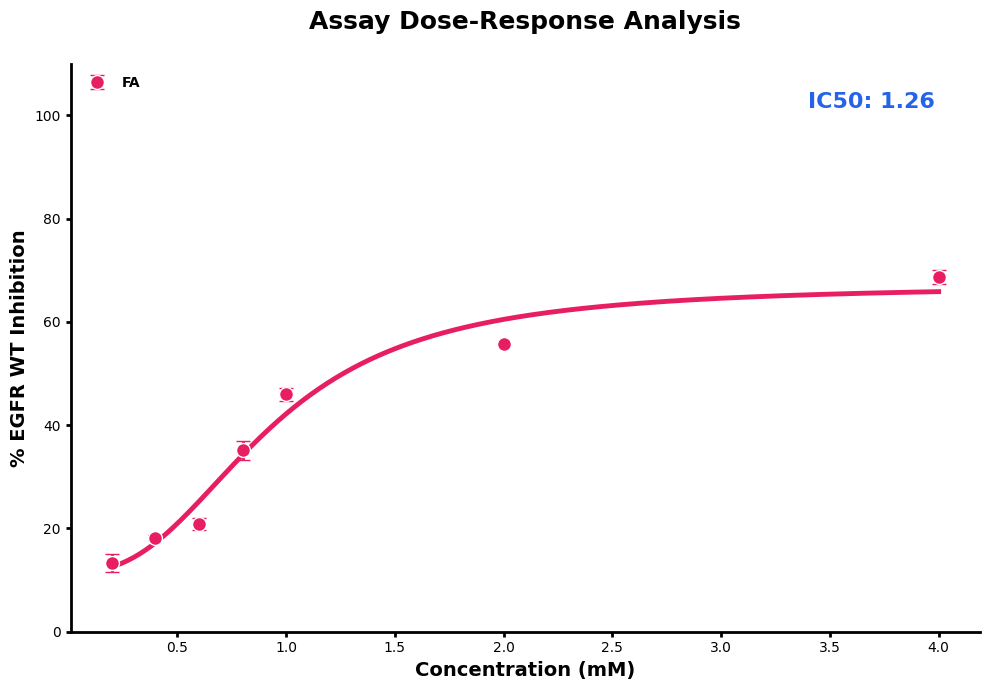

In [3]:
try:
    SCIENTIFIC_PINK = "#e81e63"
    SCIENTIFIC_BLUE = "#2563eb"
    AXIS_COLOR = "#000000"

    # Configure thick axes and clean style
    plt.rcParams['axes.linewidth'] = 2.0
    plt.rcParams['xtick.major.width'] = 2.0
    plt.rcParams['ytick.major.width'] = 2.0
    plt.rcParams['xtick.direction'] = 'out'
    plt.rcParams['ytick.direction'] = 'out'
    
    fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    ic50_results = []
    
    if 'Compound' in df.columns:
        # Horizontal Format Logic
        value_cols = [c for c in df.columns if c != 'Compound']
        x_numeric = np.array([float(re.search(r'(\d+)', c).group(1)) if re.search(r'(\d+)', c) else c for c in value_cols])
        x_smooth = np.linspace(min(x_numeric), max(x_numeric), 300)
        
        for i, (idx, row) in enumerate(df.iterrows()):
            name = str(row['Compound']).strip()
            parsed = [parse_val_sd(v) for v in row[value_cols]]
            y_vals = np.array([p[0] for p in parsed])
            y_errs = np.array([p[1] for p in parsed])
            
            ax.errorbar(x_numeric, y_vals, yerr=y_errs, fmt='o', color=SCIENTIFIC_PINK, 
                        ecolor=SCIENTIFIC_PINK, elinewidth=2, capsize=5, markersize=10, 
                        markeredgecolor='white', label=name, zorder=5)
            
            ic50, popt = calculate_ic50(x_numeric, y_vals)
            if popt is not None:
                ax.plot(x_smooth, logistic4(x_smooth, *popt), color=SCIENTIFIC_PINK, linewidth=3.5, zorder=4)
                if ic50: ic50_results.append((name, ic50))
        col_x_name = "Concentration"
    else:
        # Vertical Format Logic
        col_x = df.columns[0]
        x_data = df[col_x].values
        x_smooth = np.linspace(min(x_data), max(x_data), 300)
        data_cols = [c for c in df.columns if c != col_x]
        
        for i, col in enumerate(data_cols):
            parsed = [parse_val_sd(v) for v in df[col]]
            y_vals = np.array([p[0] for p in parsed])
            y_errs = np.array([p[1] for p in parsed])
            
            ax.errorbar(x_data, y_vals, yerr=y_errs, fmt='o', color=SCIENTIFIC_PINK, 
                        ecolor=SCIENTIFIC_PINK, elinewidth=2, capsize=5, markersize=10, 
                        markeredgecolor='white', label=col, zorder=5)
            
            ic50, popt = calculate_ic50(x_data, y_vals)
            if popt is not None:
                ax.plot(x_smooth, logistic4(x_smooth, *popt), color=SCIENTIFIC_PINK, linewidth=3.5, zorder=4)
                if ic50: ic50_results.append((col, ic50))
        col_x_name = col_x

    # Annotation inside graph
    if ic50_results:
        summary = "\n".join([f"IC50: {ic:.2f}" for n, ic in ic50_results])
        ax.text(0.95, 0.95, summary, transform=ax.transAxes, color=SCIENTIFIC_BLUE, 
                fontweight='black', fontsize=16, va='top', ha='right', 
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=10))

    plt.ylabel('% EGFR WT Inhibition', fontweight='bold', fontsize=14, color=AXIS_COLOR)
    plt.xlabel(col_x_name, fontweight='bold', fontsize=14, color=AXIS_COLOR)
    plt.title('Assay Dose-Response Analysis', fontweight='bold', pad=25, fontsize=18)
    plt.ylim(0, 110)
    plt.legend(frameon=False, prop={'weight':'bold'})
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Visualization error: {e}")